In [1]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt') 

# 간단한 문장 데이터
corpus = [
    'I love natural language processing.',
    'Word embeddings capture semantic relationships.',
    'Word2Vec is a popular algorithm in NLP.'
]

# 문장을 단어로 토큰화
tokenized_corpus = [word_tokenize(sentence.lower()) for sentence in corpus]

# Word2Vec 모델 학습
# sentences: 학습에 사용될 문장데이터로 토큰화된 단어 리스트로 제공
# vector_size: 단어를 표현하는 벡터의 차원 지정(클 수록 정교해짐)
# window=3, 주어진 단어를 기준으로 좌우 3개의 단어를 문맥으로 사용
# workers: 모델 학습에 사용할 병렬 처리를 위한 CPU 코어의 수 지정
model = Word2Vec(sentences=tokenized_corpus, vector_size=10, 
                 window=3, min_count=1, workers=8)

# 단어 벡터 확인
word_vectors = model.wv
print("Vector for 'word':", word_vectors['word'])

# 유사한 단어 찾기
similar_words = model.wv.most_similar('word', topn=3)
print("Words similar to 'word':", similar_words)

C:\ProgramData\anaconda3\lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been deprecated
  "class": algorithms.Blowfish,


Vector for 'word': [ 0.05455794  0.08345953 -0.01453741 -0.09208143  0.04370552  0.00571785
  0.07441908 -0.00813283 -0.02638414 -0.08753009]
Words similar to 'word': [('in', 0.42731544375419617), ('love', 0.2941223382949829), ('nlp', 0.2324305772781372)]


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\S.T.Hwang\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


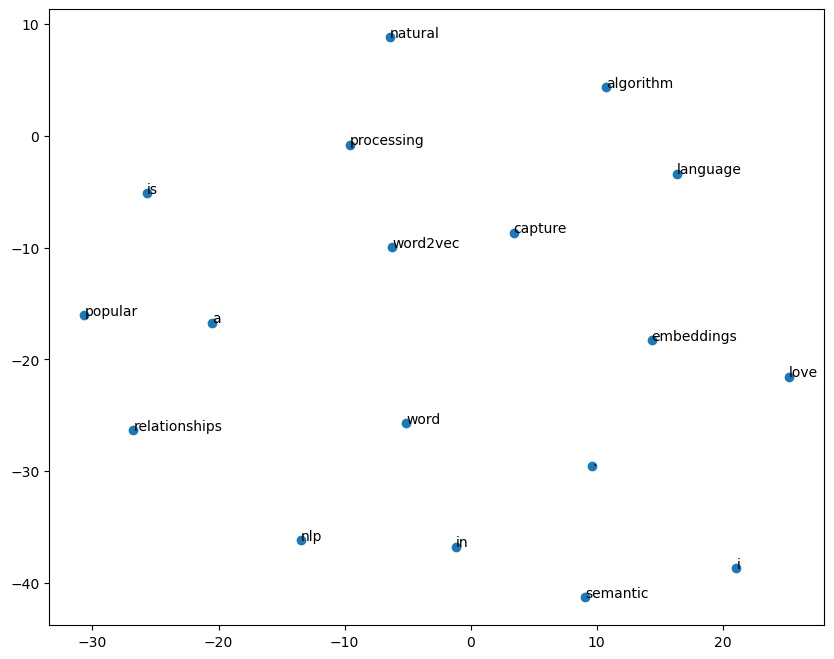

In [2]:
# 시각화를 위한 t-SNE
from sklearn.manifold import TSNE

# t-SNE 모델 생성
# n_components=2로 설정하면 2차원으로 보여줌
# perplexity: 분석시 고려하는 이웃의 수
tsne = TSNE(n_components=2, perplexity=10, random_state=42)

# 모든 단어에 대해 t-SNE 적용
word_vectors_2d = tsne.fit_transform(word_vectors.vectors)

# 2차원 플로팅
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1])

# 각 점에 해당하는 단어 레이블 추가
for word, (x, y) in zip(word_vectors.index_to_key, word_vectors_2d):
    ax.text(x, y, word)

plt.show()

In [3]:
%matplotlib widget

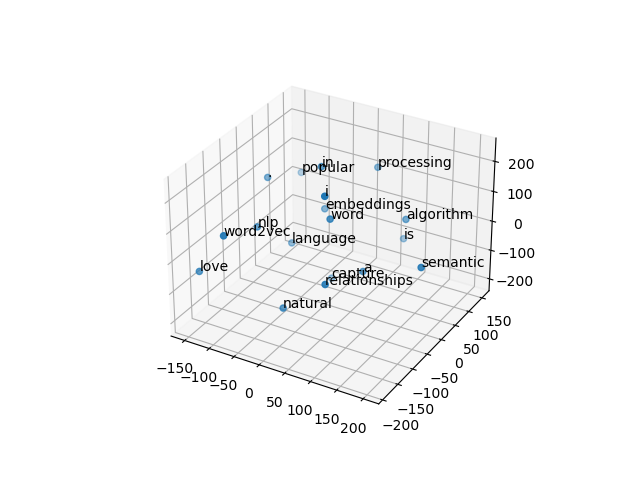

In [5]:
# 3차원 플로팅

tsne = TSNE(n_components=3, perplexity=10, random_state=42)

# 모든 단어에 대해 t-SNE 적용
word_vectors_3d = tsne.fit_transform(word_vectors.vectors)

import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(word_vectors_3d[:, 0], word_vectors_3d[:, 1], 
           word_vectors_3d[:, 2])

# 각 점에 해당하는 단어 레이블 추가
for word, (x, y, z) in zip(word_vectors.index_to_key,
                           word_vectors_3d):
    ax.text(x, y, z, word)

plt.show()

In [2]:
from gensim.scripts import word2vec2tensor

# Word2Vec 모델 저장 (save_word2vec_format 사용)
model.wv.save_word2vec_format("word_vectors.kv", binary=False)

# word2vec2tensor 호출
word2vec2tensor.word2vec2tensor("word_vectors.kv", 
                                "word_vectors_tensor", binary=False)

## 한글 뉴스 word2vec

In [7]:
# 한글 출력을 위한 폰트 설정
from matplotlib import font_manager, rc

# 한글 폰트 경로 설정
font_path = "C:/Windows/Fonts/malgun.ttf" 

# 한글 폰트 설정
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc('font', family=font_name)

In [8]:
from nltk.tokenize import sent_tokenize,word_tokenize

file='C:/Temp/korean_news.txt'

# 파일 열기 (읽기 모드로)
with open(file, 'r', encoding='utf-8') as ff:
    file_content = ff.read()

file_content.replace('\n','') # 빈 줄 제거

# 문장, 단어 토큰화
sentences = sent_tokenize(file_content) # 문장 토큰화
tokenized_corpus = [word_tokenize(sentence) 
                    for sentence in sentences]

# Stopwords 적용
Ko_stopwords=['는','지','은','[',']','(',')','/',':'
              ,'.',',','월','일','지','건']
result = [] 
for w in tokenized_corpus: # 불용어 적용
    if w not in Ko_stopwords: # 불용어 사전에 없다면
        result.append(w) 

C:\ProgramData\anaconda3\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


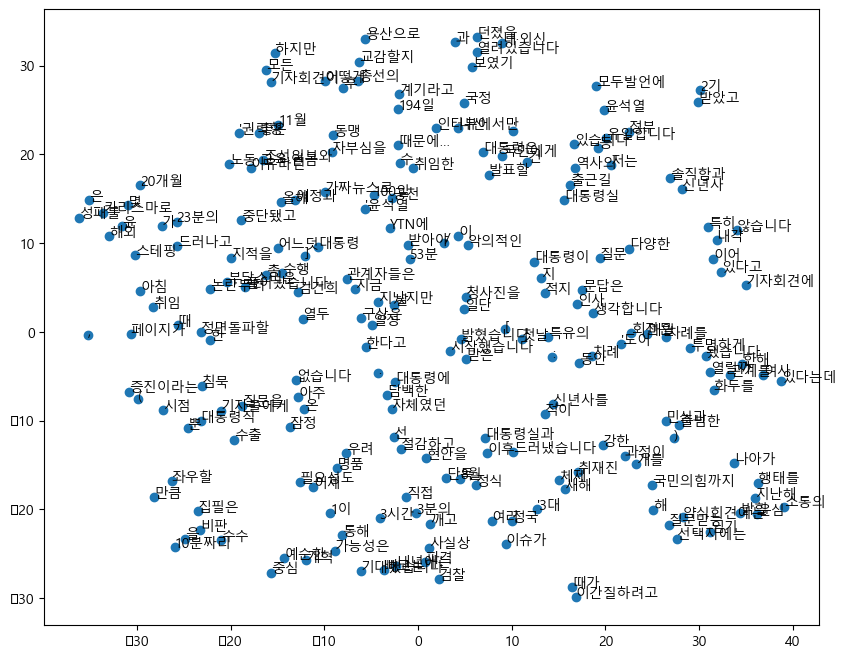

In [9]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from gensim.models import Word2Vec

# Word2Vec 모델 학습
model = Word2Vec(sentences=result, vector_size=10, 
                 window=3, min_count=1, workers=8)

# t-SNE 모델 생성
tsne = TSNE(n_components=2, perplexity=10, random_state=42)

# 모든 단어에 대해 t-SNE 적용
word_vectors = model.wv
word_vectors_2d = tsne.fit_transform(word_vectors.vectors)

# 2차원 플로팅
import matplotlib.pyplot as plt 
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(word_vectors_2d[:, 0], word_vectors_2d[:, 1])

# 각 점에 해당하는 단어 레이블 추가
for word, (x, y) in zip(word_vectors.index_to_key, word_vectors_2d):
    ax.text(x, y, word)

plt.show()